In [1]:
import shap
import joblib
import pandas as pd
from scipy.io import arff
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
data, meta = arff.loadarff("../dataset/jm1.arff")
df = pd.DataFrame(data)

# Remove duplicates
df = df.drop_duplicates()

# Convert target
df["defects"] = df["defects"].map({
    b"false": 0,
    b"true": 1
})

X = df.drop("defects", axis=1)
y = df["defects"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
xgb_model = joblib.load("../models/xgboost_model.pkl")

In [4]:
explainer = shap.TreeExplainer(xgb_model)

In [5]:
shap_values = explainer.shap_values(X_test)

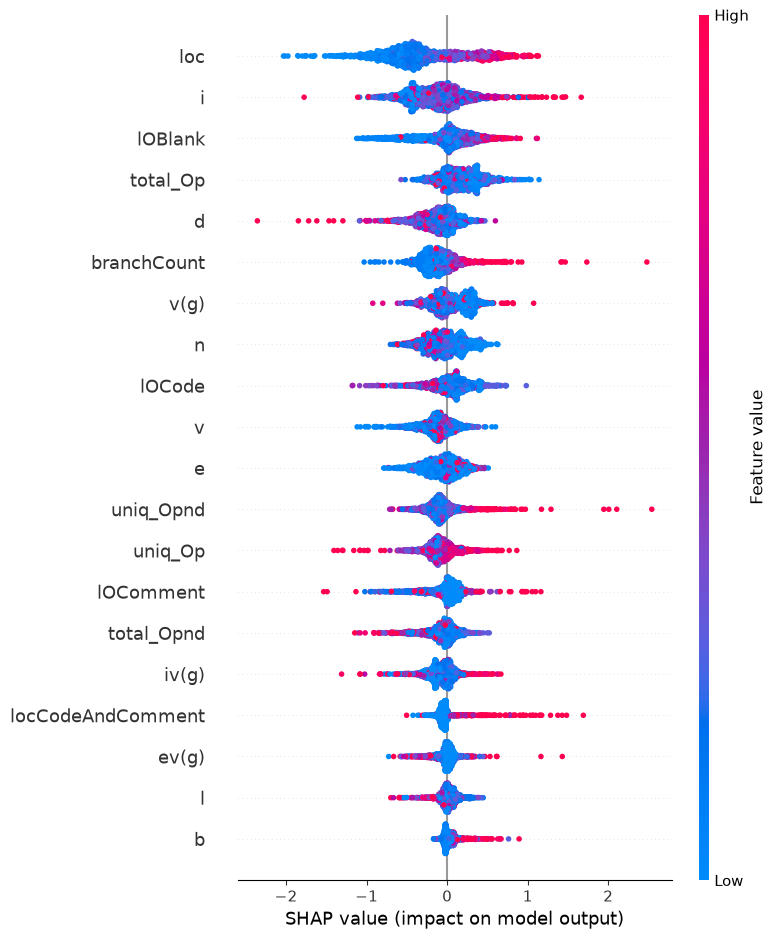

In [6]:
shap.summary_plot(shap_values, X_test)

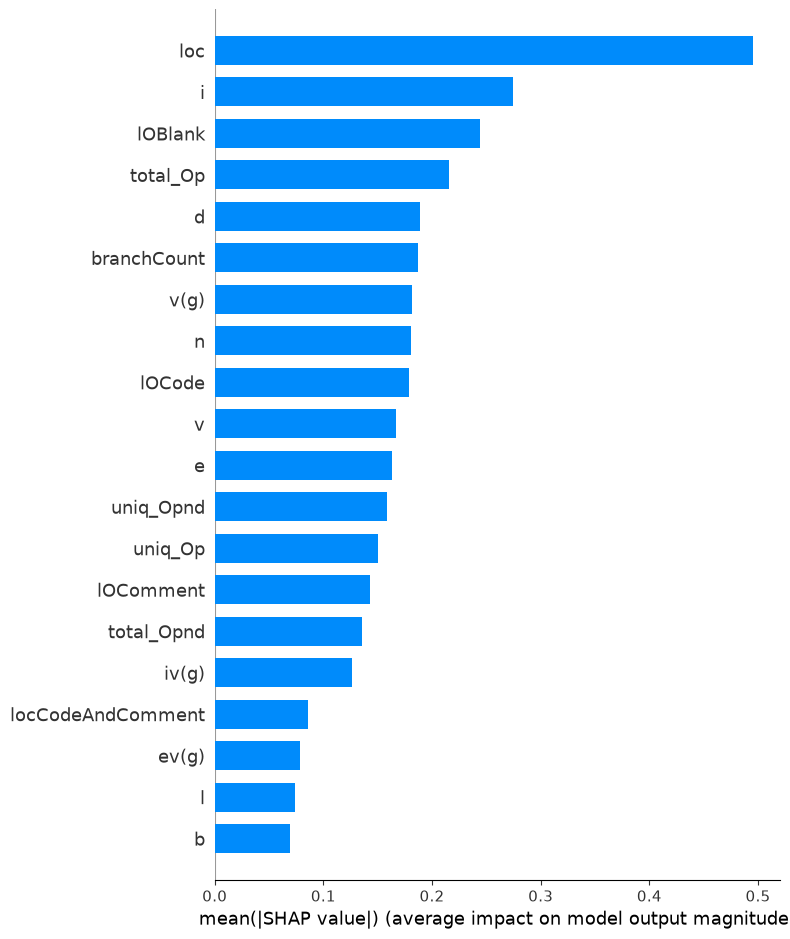

In [7]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

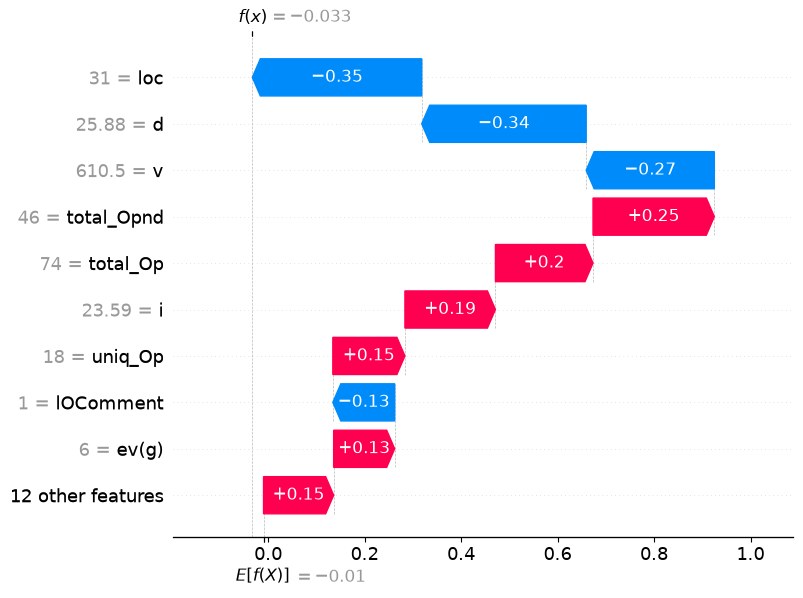

In [8]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    )
)

In [9]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(shap_values).mean(axis=0)
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
0,loc,0.495430
8,i,0.274366
14,lOBlank,0.244321
18,total_Op,0.215190
7,d,0.188536
20,branchCount,0.187243
1,v(g),0.181271
4,n,0.180382
12,lOCode,0.178622
5,v,0.166968


In [10]:
sample_index = 0

print("Actual:", y_test.iloc[sample_index])
print("Prediction:", xgb_model.predict(X_test.iloc[[sample_index]])[0])

Actual: 0
Prediction: 0


In [11]:
X_test.iloc[sample_index]

loc                     31.00
v(g)                     9.00
ev(g)                    6.00
iv(g)                    3.00
n                      120.00
v                      610.50
l                        0.04
d                       25.88
i                       23.59
e                    15796.57
b                        0.20
t                      877.59
lOCode                  23.00
lOComment                1.00
lOBlank                  5.00
locCodeAndComment        0.00
uniq_Op                 18.00
uniq_Opnd               16.00
total_Op                74.00
total_Opnd              46.00
branchCount             17.00
Name: 6390, dtype: float64

In [12]:
explanation = explainer(X_test)

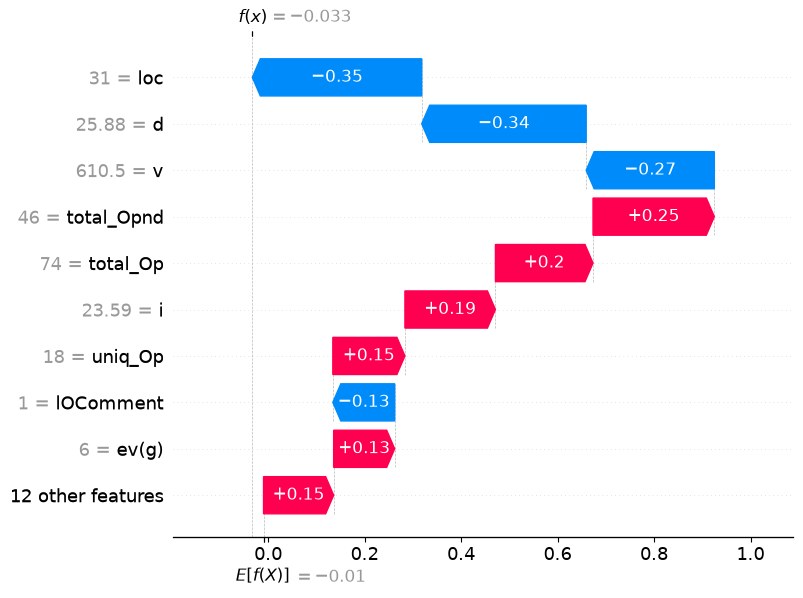

In [13]:
shap.plots.waterfall(explanation[sample_index])

In [14]:
import pandas as pd
import numpy as np

sample = 0

contributions = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": X_test.iloc[sample].values,
    "SHAP Value": explanation.values[sample]
})

contributions["Absolute SHAP"] = np.abs(contributions["SHAP Value"])

top_features = contributions.sort_values(
    by="Absolute SHAP",
    ascending=False
)

top_features.head(10)

,Feature,Value,SHAP Value,Absolute SHAP
0,loc,31.00,-0.351163,0.351163
7,d,25.88,-0.340966,0.340966
5,v,610.50,-0.265700,0.265700
19,total_Opnd,46.00,0.251507,0.251507
18,total_Op,74.00,0.202327,0.202327
8,i,23.59,0.187657,0.187657
16,uniq_Op,18.00,0.149456,0.149456
13,lOComment,1.00,-0.128250,0.128250
2,ev(g),6.00,0.126527,0.126527
10,b,0.20,0.104884,0.104884
